In [97]:
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.cm as cm

Case 1: Shifted Poschl Teller (nu = 0)
Case 2: Standard Poschl Teller (nu = -1)
Case 3: Modified Poschl Teller (nu < 0)
Case 4: Confining well (nu > 0) (NOTE : Need to keep a1 < 0)

In [137]:
a1 = -1.0 #NOTE : Always keep negative (positive values will result the potential being non-hermitian)
a2 = 1.0
nu = -1.0

In [99]:
def sech(x):
    return 1/(np.cosh(x))

In [100]:
def build_Grid(L, N):
    x = np.linspace(-L, L, N)
    dx = x[1] - x[0]
    return x, dx

def volcano_potential(x, a1, a2, nu):
    cosh_term = np.cosh(x)
    sech_term = sech(x)

    return -1*((a1 * (cosh_term)**(2 * nu)) + (a2 * (sech_term)**2))

def solve_schrodinger(x, dx, V_array):
    size = len(x)
    
    array = np.ones(size)
    array_off = np.ones(size - 1)
    
    V_matrice = np.diag(V_array)
    T_matrice = (2*np.diag(array, k = 0) + -1*np.diag(array_off, k = 1) + -1*np.diag(array_off, k = -1)) / (2 * dx * dx)
    H_matrice = T_matrice + V_matrice
    
    eigenvalue, eigenvector = np.linalg.eigh(H_matrice)

    return eigenvalue, eigenvector

In [143]:
def x_pos_basis(x):
    return np.diag(x)

def P_pos_basis(x, dx):
    size = len(x)
    array = np.ones(size)
    array_off = np.ones(size - 1)

    p_matrice = -1j * (np.diag(array_off, k = 1) - np.diag(array_off, k = -1)) / (2 * dx)
    return p_matrice

def energy_matrices(x, dx, nu):

    V_array = volcano_potential(x, a1, a2, nu)
    x_pos_matrice = x_pos_basis(x)
    P_pos_matrice = P_pos_basis(x, dx)
    eigenvalue, eigenvector = solve_schrodinger(x, dx, V_array)

    x_matrice =  eigenvector.T @ x_pos_matrice @ eigenvector
    p_matrice = eigenvector.T @ P_pos_matrice @ eigenvector

    return x_matrice, p_matrice, eigenvalue

In [144]:
def get_unitary(energies, t):
    exponent = np.exp(-1j * energies * t)
    return np.diag(exponent)

def calculate_otoc(t, energies, x_matrice_0, p_matrice_0, n):
    U_t = get_unitary(energies, t)
    x_t = U_t.conj().T @ x_matrice_0 @ U_t

    comm = x_t @ p_matrice_0 - p_matrice_0 @ x_t
    intensity = comm.conj().T @ comm
    
    return intensity[n, n]

In [ ]:
L = 10.0  
N = 500   # Change this to modify grid space (N x N)
n_values = [1, 3, 5]  # Change this to modify n parameter
t_max = 150  # Change this to modify time scale [0, t_max]

In [145]:
def run_simulation(N, t_max, n, nu):
    x, dx = build_Grid(L, N)
    x_matrice, p_matrice, energies = energy_matrices(x, dx, nu)
    t_range = np.linspace(0, t_max, 300)
    otoc_values = []

    for t in t_range:
        otoc_values.append(calculate_otoc(t, energies, x_matrice, p_matrice, n))

    return otoc_values

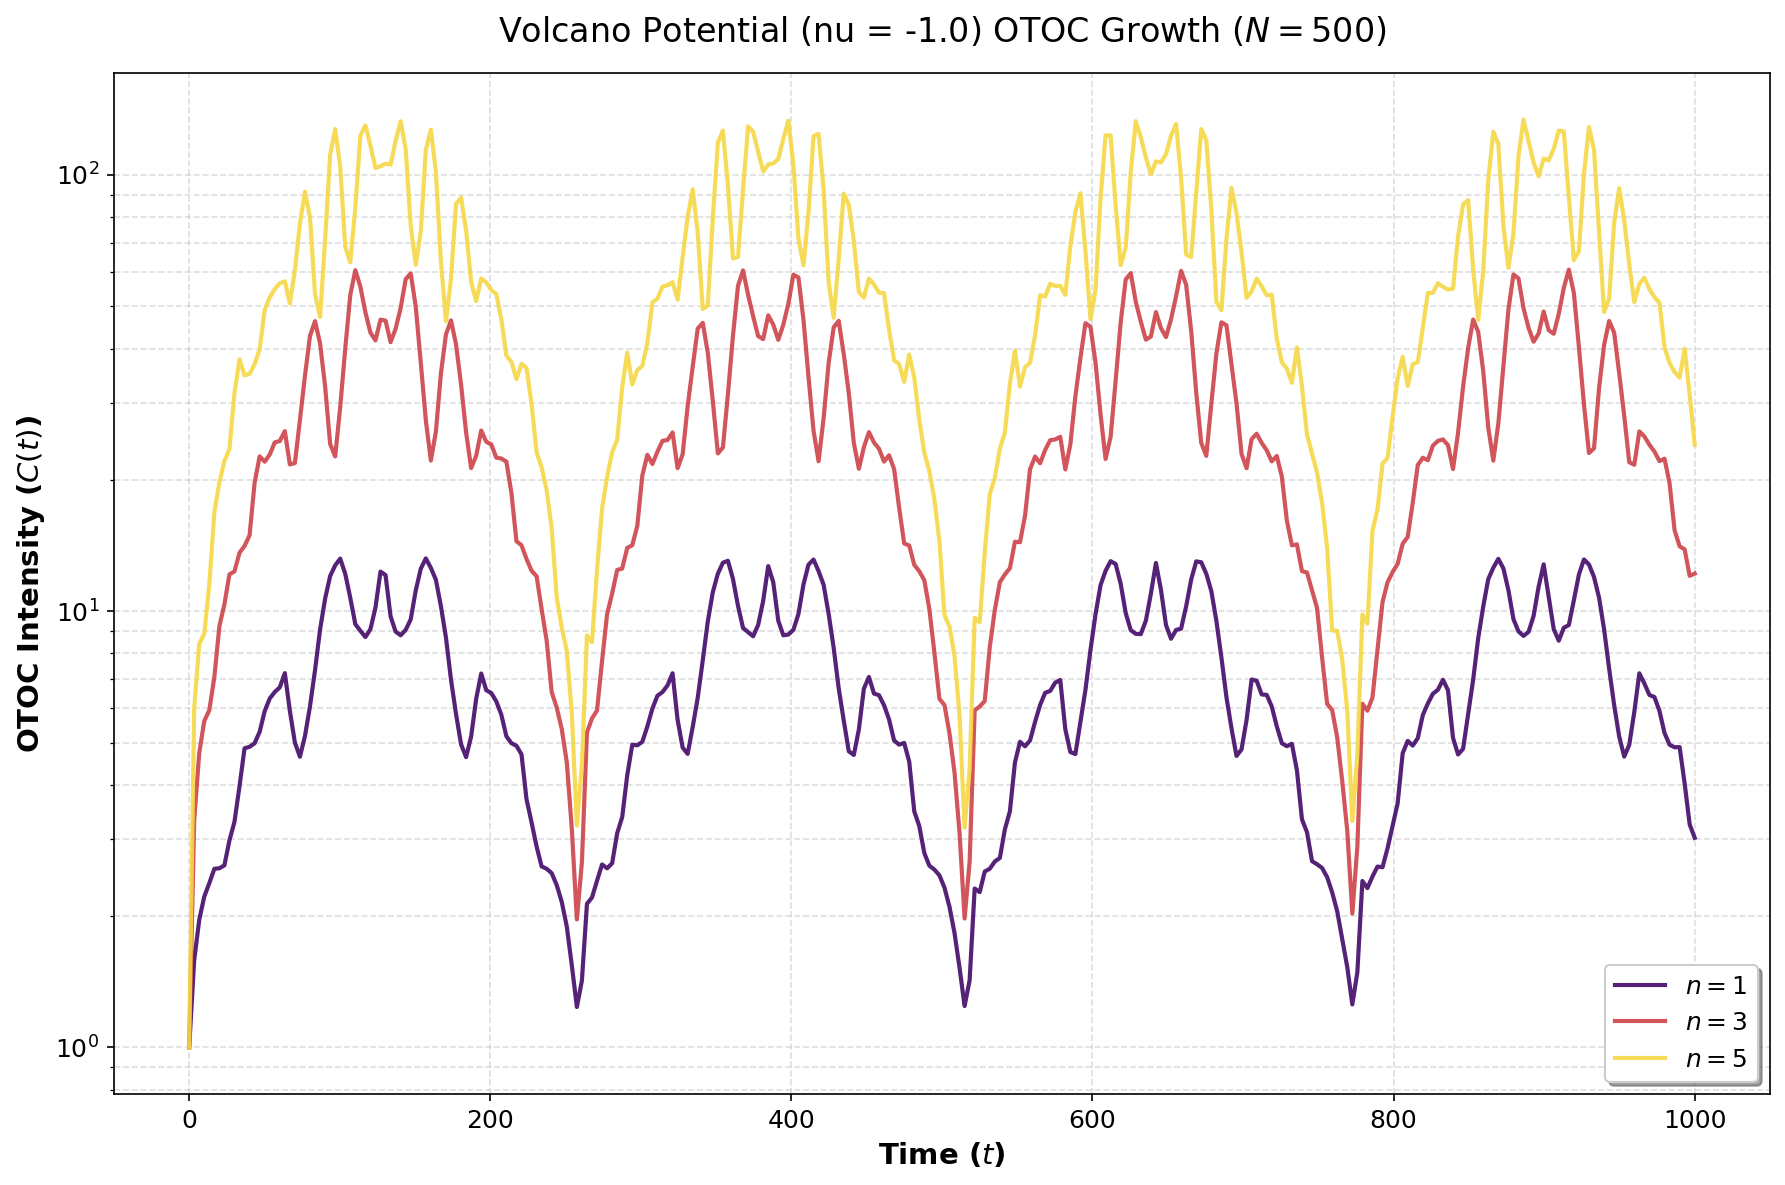

In [ ]:
plt.figure(figsize=(10, 6), dpi = 150)
colors = cm.inferno(np.linspace(0.2, 0.9, len(n_values)))

t_range = np.linspace(0, t_max, 300)
results = []
for i, n in enumerate(n_values):
    results = run_simulation(N, t_max, n, nu)
    results = np.real(results)

    plt.plot(t_range, results, 
             label=f'$n = {n}$', # using LaTeX formatting for math text
             color=colors[i], 
             linewidth=2, 
             alpha=0.9)

plt.grid(True, which="both", ls="--", alpha=0.4)  
plt.yscale('log')
plt.xlabel('Time ($t$)', fontsize=14, fontweight='bold')
plt.ylabel('OTOC Intensity ($C(t)$)', fontsize=14, fontweight='bold')
plt.title(f'Volcano Potential (nu = {nu}) OTOC Growth ($N={N}$)', fontsize=16, pad=15)
plt.legend(fontsize=12, frameon=True, loc='lower right', shadow=True)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout() 
plt.show()

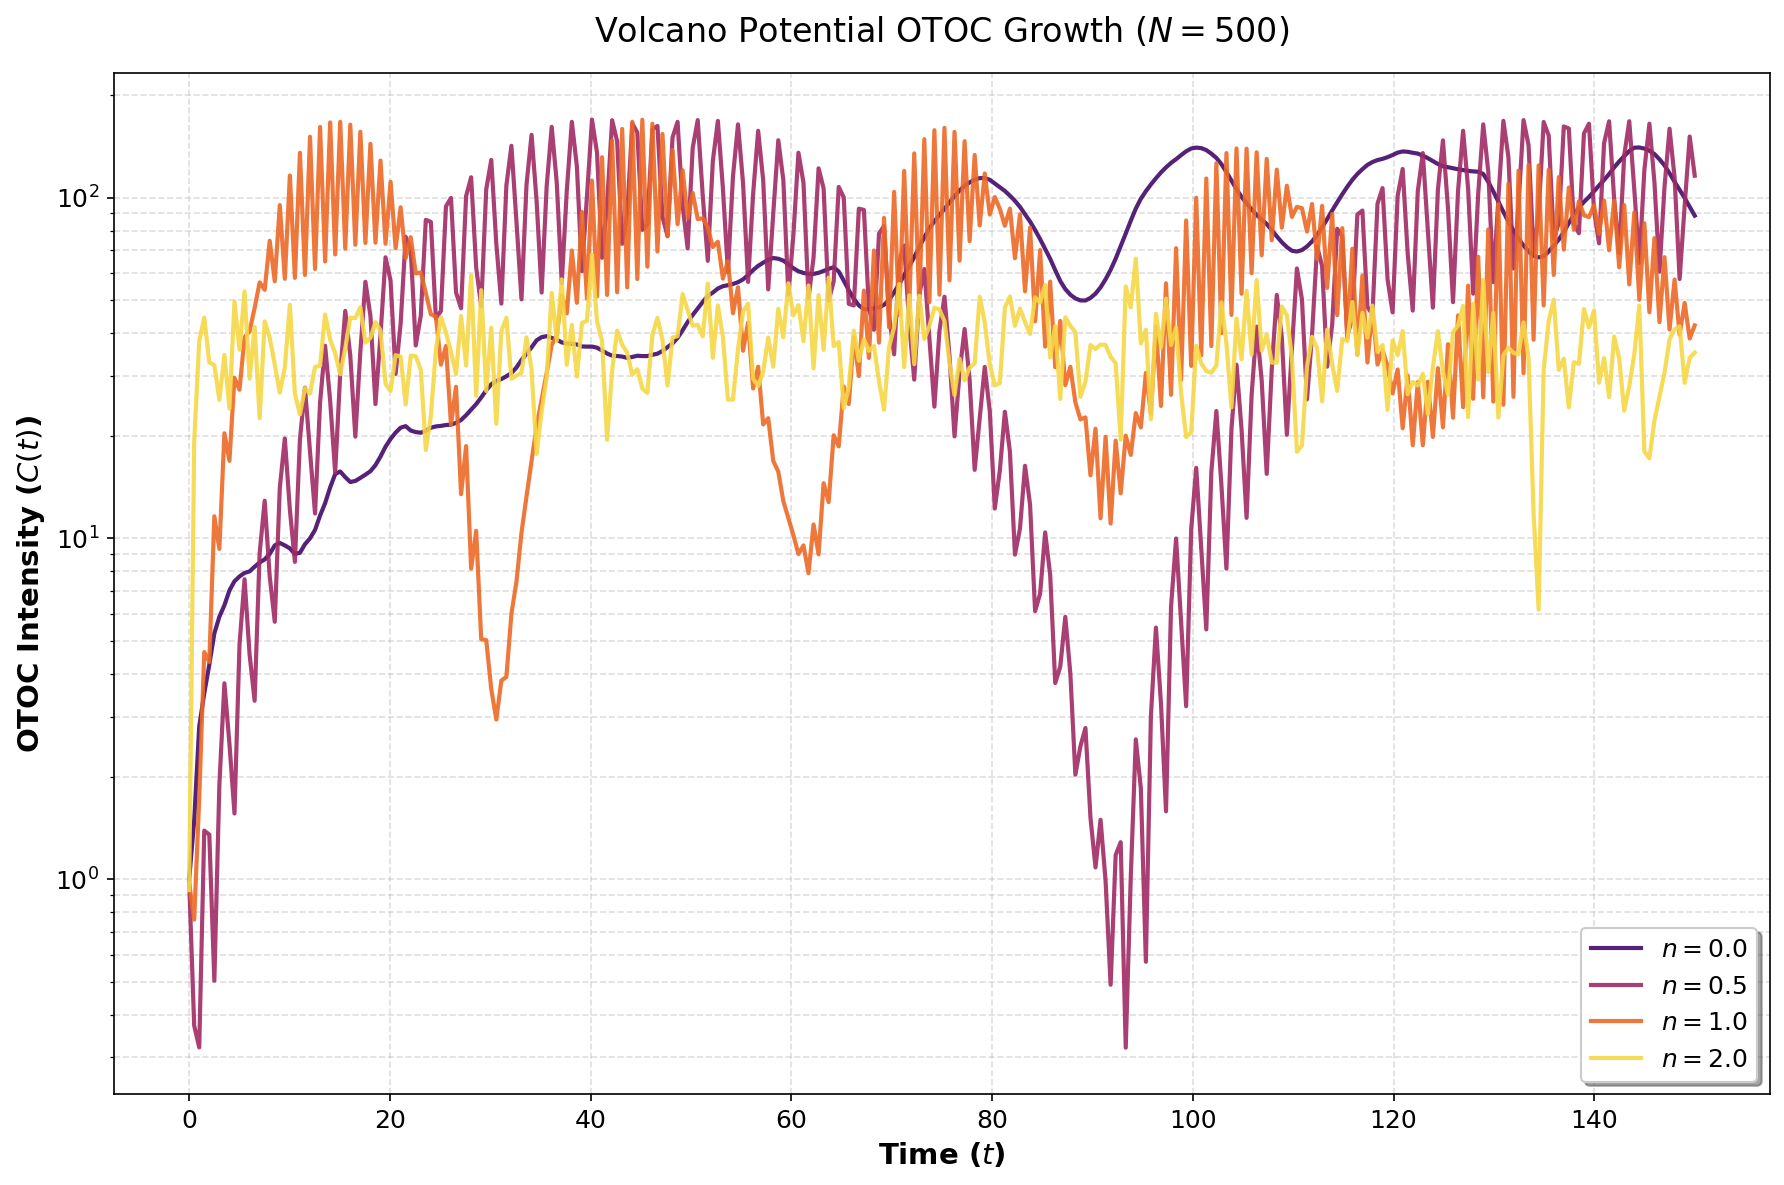

In [ ]:
nu_values = [0.0, 0.5, 1.0, 2.0]
t_range = np.linspace(0, t_max, 300)

plt.figure(figsize=(10, 6), dpi = 150)
colors = cm.inferno(np.linspace(0.2, 0.9, len(nu_values)))
n = 5
results = []
for i, nu_val in enumerate(nu_values):
    results = run_simulation(N, t_max, n, nu_val)
    results = np.real(results)

    plt.plot(t_range, results, 
             label=f'$n = {nu_val}$', # using LaTeX formatting for math text
             color=colors[i], 
             linewidth=2, 
             alpha=0.9)

plt.grid(True, which="both", ls="--", alpha=0.4)  
plt.yscale('log')
plt.xlabel('Time ($t$)', fontsize=14, fontweight='bold')
plt.ylabel('OTOC Intensity ($C(t)$)', fontsize=14, fontweight='bold')
plt.title(f'Volcano Potential OTOC Growth ($N={N}$)', fontsize=16, pad=15)
plt.legend(fontsize=12, frameon=True, loc='lower right', shadow=True)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout() 
plt.show()

